Inp: C:\Users\Usuario\Desktop\MC949\MC949-Visao-Computacional\data\T4\imagens\antiga_7.jpg True True 2 0.5
	image size: (260, 194, 3)
	detect 1 faces
Imagem restaurada salva em: C:\Users\Usuario\Desktop\MC949\MC949-Visao-Computacional\notebooks\T4\results\antiga_7.jpg


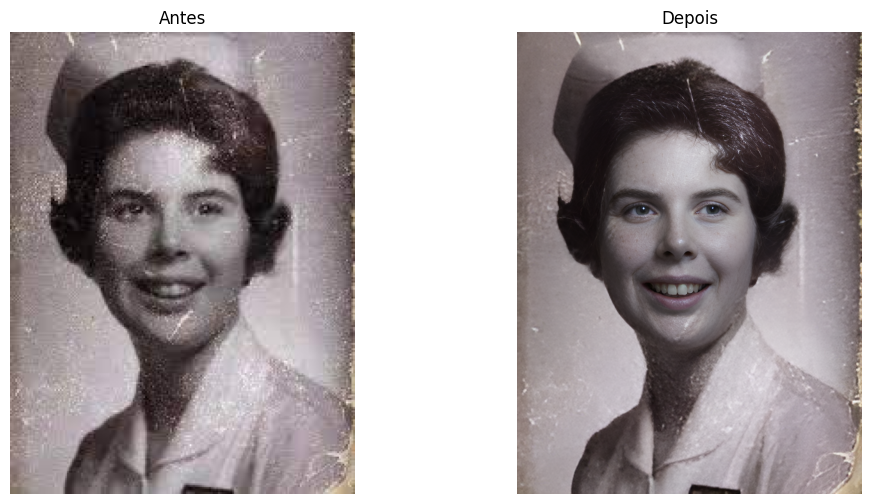

In [1]:
from codeformer.app import inference_app
import shutil
import cv2
import matplotlib.pyplot as plt
from canon.T4.utils import load_image_and_masks, get_image_path  # seu carregador de imagens personalizado
import os
from PIL import Image

def ensure_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

# -------------------------
# Diretórios
# -------------------------
current_dir = os.getcwd()
results_dir = os.path.join(current_dir, "results")
ensure_dir(results_dir)

# -------------------------
# Pegando imagem original
# -------------------------
img_path = get_image_path("antiga_7")

# -------------------------
# Rodando o modelo
# -------------------------
out = inference_app(
    image=str(img_path),
    background_enhance=True,
    face_upsample=True,
    upscale=2,
    codeformer_fidelity=0.5
)

# -------------------------
# Salvando no diretório results/
# -------------------------
output_name = os.path.basename(img_path)
final_path = os.path.join(results_dir, output_name)

shutil.move(out, final_path)

print("Imagem restaurada salva em:", final_path)

# -------------------------
# Exibir imagem antes/depois com matplotlib
# -------------------------
before = Image.open(img_path)
after = Image.open(final_path)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(before)
plt.title("Antes")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(after)
plt.title("Depois")
plt.axis("off")

plt.show()